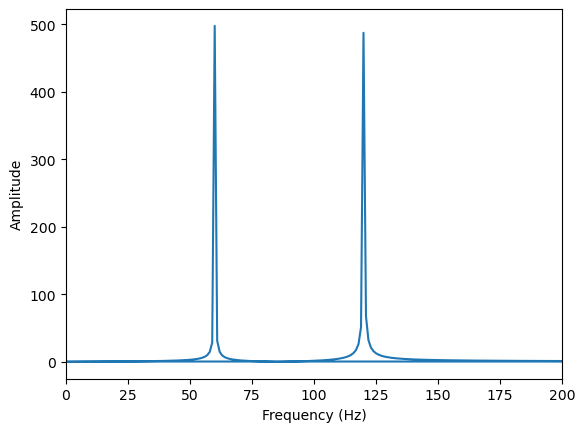

In [4]:
# make FFT of two superimposed sine waves with different frequencies and amplitudes
import numpy as np
import matplotlib.pyplot as plt

# generate two sine waves with different frequencies and amplitudes
f1 = 60
f2 = 120
A1 = 1
A2 = 1
fs = 1000
N = 1000

# generate time vector
t = np.linspace(0, N/fs, N)

# generate two sine waves
x1 = A1*np.sin(2*np.pi*f1*t)
x2 = A2*np.sin(2*np.pi*f2*t)

# superimpose the two sine waves
x = x1 + x2

# compute FFT
X = np.fft.fft(x)

# compute frequency vector
f = np.fft.fftfreq(N, 1/fs)

# plot the FFT
plt.plot(f, np.abs(X))
plt.xlabel('Frequency (Hz)')
plt.xlim(0, 200)
plt.ylabel('Amplitude')
plt.show()



In [ ]:
# now can you write a script to simulate what it would look like of i combined these two signal in Say RF splitter
"""
RF Combiner Spectrum Analyzer
Simulates an RF combiner with multiple input signals and plots the frequency spectrum.
Handles frequency mixing and intermodulation products.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from scipy.fft import fft, fftfreq

class RFCombiner:
    """
    Simulates an RF combiner that combines multiple signals and handles frequency mixing.
    """
    
    def __init__(self, sampling_rate=10e9, duration=1e-6, num_points=10000):
        """
        Initialize the RF combiner.
        
        Parameters:
        -----------
        sampling_rate : float
            Sampling rate in Hz (default: 10 GHz)
        duration : float
            Signal duration in seconds (default: 1 microsecond)
        num_points : int
            Number of time points (default: 10000)
        """
        self.sampling_rate = sampling_rate
        self.duration = duration
        self.num_points = num_points
        self.time = np.linspace(0, duration, num_points)
        self.signals = []
        
    def add_signal(self, frequency, amplitude, phase=0, name=None):
        """
        Add a signal to the combiner.
        
        Parameters:
        -----------
        frequency : float
            Frequency in Hz
        amplitude : float
            Amplitude (linear scale)
        phase : float
            Phase in degrees (default: 0)
        name : str
            Optional name for the signal
        """
        signal_dict = {
            'frequency': frequency,
            'amplitude': amplitude,
            'phase': phase,
            'name': name or f'Signal {len(self.signals) + 1}'
        }
        self.signals.append(signal_dict)
        
    def clear_signals(self):
        """Clear all signals from the combiner."""
        self.signals = []
        
    def generate_signal(self, signal_dict):
        """
        Generate a single signal based on parameters.
        
        Parameters:
        -----------
        signal_dict : dict
            Dictionary containing frequency, amplitude, phase, and name
            
        Returns:
        --------
        numpy.ndarray
            Time-domain signal
        """
        freq = signal_dict['frequency']
        amp = signal_dict['amplitude']
        phase_rad = np.deg2rad(signal_dict['phase'])
        
        return amp * np.cos(2 * np.pi * freq * self.time + phase_rad)
    
    def combine_signals(self, nonlinearity=0.0):
        """
        Combine all signals and generate mixing products.
        
        Parameters:
        -----------
        nonlinearity : float
            Degree of nonlinearity (0 = linear, >0 adds intermodulation products)
            
        Returns:
        --------
        numpy.ndarray
            Combined time-domain signal
        """
        if not self.signals:
            return np.zeros_like(self.time)
        
        # Linear combination
        combined = np.zeros_like(self.time)
        for signal_dict in self.signals:
            combined += self.generate_signal(signal_dict)
        
        # Add nonlinearity (creates intermodulation products)
        if nonlinearity > 0:
            combined = combined + nonlinearity * combined**2 + (nonlinearity**2) * combined**3
        
        return combined
    
    def compute_spectrum(self, signal):
        """
        Compute the frequency spectrum of a signal.
        
        Parameters:
        -----------
        signal : numpy.ndarray
            Time-domain signal
            
        Returns:
        --------
        freqs : numpy.ndarray
            Frequency array in Hz
        magnitude : numpy.ndarray
            Magnitude spectrum in dBm (normalized)
        """
        # Compute FFT
        spectrum = fft(signal)
        freqs = fftfreq(len(signal), 1/self.sampling_rate)
        
        # Only take positive frequencies
        positive_freqs = freqs[:len(freqs)//2]
        magnitude = np.abs(spectrum[:len(freqs)//2])
        
        # Convert to dBm (with normalization)
        # Avoid log(0) by adding a small epsilon
        magnitude_dbm = 20 * np.log10(magnitude + 1e-12)
        # Normalize to peak
        magnitude_dbm = magnitude_dbm - np.max(magnitude_dbm)
        
        return positive_freqs, magnitude_dbm
    
    def plot_spectrum(self, nonlinearity=0.0, figsize=(14, 10)):
        """
        Plot the time-domain signals and frequency spectrum.
        
        Parameters:
        -----------
        nonlinearity : float
            Degree of nonlinearity for mixing products
        figsize : tuple
            Figure size (width, height)
        """
        fig = plt.figure(figsize=figsize)
        
        # Create subplots
        gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
        ax_time_individual = fig.add_subplot(gs[0, :])
        ax_time_combined = fig.add_subplot(gs[1, :])
        ax_spectrum = fig.add_subplot(gs[2, :])
        
        # Plot individual signals
        for signal_dict in self.signals:
            signal = self.generate_signal(signal_dict)
            ax_time_individual.plot(self.time * 1e9, signal, 
                                   label=f"{signal_dict['name']}: {signal_dict['frequency']/1e9:.3f} GHz, "
                                         f"Amp={signal_dict['amplitude']:.2f}, Phase={signal_dict['phase']:.1f}°",
                                   alpha=0.7)
        
        ax_time_individual.set_xlabel('Time (ns)')
        ax_time_individual.set_ylabel('Amplitude')
        ax_time_individual.set_title('Individual Input Signals')
        ax_time_individual.legend(fontsize=8)
        ax_time_individual.grid(True, alpha=0.3)
        
        # Plot combined signal
        combined = self.combine_signals(nonlinearity)
        ax_time_combined.plot(self.time * 1e9, combined, color='purple', linewidth=1.5)
        ax_time_combined.set_xlabel('Time (ns)')
        ax_time_combined.set_ylabel('Amplitude')
        title = 'Combined Output Signal'
        if nonlinearity > 0:
            title += f' (Nonlinearity: {nonlinearity:.3f})'
        ax_time_combined.set_title(title)
        ax_time_combined.grid(True, alpha=0.3)
        
        # Plot spectrum
        freqs, magnitude = self.compute_spectrum(combined)
        ax_spectrum.plot(freqs / 1e9, magnitude, color='red', linewidth=1.5)
        
        # Mark input frequencies
        for signal_dict in self.signals:
            freq_ghz = signal_dict['frequency'] / 1e9
            ax_spectrum.axvline(freq_ghz, color='blue', linestyle='--', alpha=0.5, linewidth=1)
            ax_spectrum.text(freq_ghz, -5, signal_dict['name'], 
                           rotation=90, verticalalignment='top', fontsize=8)
        
        ax_spectrum.set_xlabel('Frequency (GHz)')
        ax_spectrum.set_ylabel('Magnitude (dBm, normalized)')
        ax_spectrum.set_title('Output Spectrum (FFT)')
        ax_spectrum.grid(True, alpha=0.3)
        ax_spectrum.set_ylim([-80, 5])
        
        plt.tight_layout()
        return fig


def example_usage():
    """
    Example usage of the RF combiner with multiple signals.
    """
    # Create RF combiner
    combiner = RFCombiner(
        sampling_rate=20e9,  # 20 GHz sampling rate
        duration=2e-6,       # 2 microsecond duration
        num_points=20000     # Number of points
    )
    
    # Add multiple signals
    combiner.add_signal(frequency=1.0e9, amplitude=1.0, phase=0, name='Signal 1')
    combiner.add_signal(frequency=1.5e9, amplitude=0.8, phase=45, name='Signal 2')
    combiner.add_signal(frequency=2.0e9, amplitude=0.6, phase=90, name='Signal 3')
    
    # Plot with linear combining (no mixing)
    print("Plotting linear combination...")
    combiner.plot_spectrum(nonlinearity=0.0)
    
    # Plot with nonlinearity (shows intermodulation products)
    print("Plotting with nonlinearity (intermodulation products)...")
    combiner.plot_spectrum(nonlinearity=0.1)
    
    plt.show()


def interactive_combiner():
    """
    Interactive version with controllable parameters.
    This is a simplified version - you can expand it with sliders if needed.
    """
    print("\n" + "="*60)
    print("Interactive RF Combiner")
    print("="*60)
    
    # Create combiner
    combiner = RFCombiner(
        sampling_rate=20e9,
        duration=2e-6,
        num_points=20000
    )
    
    # Get user input for signals
    num_signals = int(input("\nHow many signals do you want to combine? "))
    
    for i in range(num_signals):
        print(f"\n--- Signal {i+1} ---")
        freq = float(input(f"  Frequency (GHz): ")) * 1e9
        amp = float(input(f"  Amplitude (0-1): "))
        phase = float(input(f"  Phase (degrees): "))
        name = input(f"  Name (optional, press Enter to skip): ") or f"Signal {i+1}"
        
        combiner.add_signal(frequency=freq, amplitude=amp, phase=phase, name=name)
    
    # Ask about nonlinearity
    nonlin_input = input("\nInclude nonlinearity for mixing products? (y/n): ").lower()
    nonlinearity = 0.1 if nonlin_input == 'y' else 0.0
    
    # Plot
    print("\nGenerating plots...")
    combiner.plot_spectrum(nonlinearity=nonlinearity)
    plt.show()


def quick_preset(preset='two_tone'):
    """
    Quick presets for common scenarios.
    
    Parameters:
    -----------
    preset : str
        'two_tone' - Two-tone test for intermodulation
        'three_tone' - Three closely spaced tones
        'harmonic' - Fundamental and harmonics
    """
    combiner = RFCombiner(sampling_rate=20e9, duration=2e-6, num_points=20000)
    
    if preset == 'two_tone':
        combiner.add_signal(frequency=1.0e9, amplitude=1.0, phase=0, name='Tone 1')
        combiner.add_signal(frequency=1.1e9, amplitude=1.0, phase=0, name='Tone 2')
        combiner.plot_spectrum(nonlinearity=0.15)
        
    elif preset == 'three_tone':
        combiner.add_signal(frequency=1.0e9, amplitude=0.8, phase=0, name='Tone 1')
        combiner.add_signal(frequency=1.2e9, amplitude=0.8, phase=30, name='Tone 2')
        combiner.add_signal(frequency=1.4e9, amplitude=0.8, phase=60, name='Tone 3')
        combiner.plot_spectrum(nonlinearity=0.1)
        
    elif preset == 'harmonic':
        f0 = 0.5e9
        combiner.add_signal(frequency=f0, amplitude=1.0, phase=0, name='Fundamental')
        combiner.add_signal(frequency=2*f0, amplitude=0.5, phase=0, name='2nd Harmonic')
        combiner.add_signal(frequency=3*f0, amplitude=0.3, phase=0, name='3rd Harmonic')
        combiner.plot_spectrum(nonlinearity=0.05)
    
    plt.show()


if __name__ == "__main__":
    print("RF Combiner Spectrum Analyzer")
    print("="*60)
    print("\nOptions:")
    print("1. Run example with predefined signals")
    print("2. Interactive mode (input your own signals)")
    print("3. Two-tone preset")
    print("4. Three-tone preset")
    print("5. Harmonic preset")
    
    choice = input("\nSelect option (1-5): ")
    
    if choice == '1':
        example_usage()
    elif choice == '2':
        interactive_combiner()
    elif choice == '3':
        quick_preset('two_tone')
    elif choice == '4':
        quick_preset('three_tone')
    elif choice == '5':
        quick_preset('harmonic')
    else:
        print("Invalid option. Running example...")
        example_usage()

